<a href="https://colab.research.google.com/github/scudilio/FIAP_MBA-Feature_Engineering/blob/main/Aula1_missing_data_mba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MBA em Data Science - Tratamento de Dados Faltantes

**Professor:** Juliana Scudilio

**Objetivo da Aula:** Compreender e aplicar técnicas de tratamento de dados faltantes (missing data) em datasets reais de negócios.

---

## 📋 Agenda

1. Introdução ao Problema de Missing Data
2. Tipos de Dados Faltantes (MCAR, MAR, MNAR)
3. Técnicas de Tratamento:
   - Listwise Deletion
   - End of Distribution Imputation
   - Mean/Median/Mode Imputation
   - Random Imputation
   - Arbitrary Value Imputation
   - Add Variable to Denote (Flag de Missing)
4. Exercício Prático

---

## 1. Setup Inicial e Carregamento de Dados

Vamos trabalhar com um dataset de **Marketing e Vendas** de uma empresa de varejo online.

In [2]:
# Importação de bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Para reprodutibilidade
np.random.seed(42)

## 2. Introdução ao Problema de Missing Data

### Por que dados faltam?

Em projetos reais de Data Science, dados faltantes são extremamente comuns:

- **Clientes não preenchem todos os campos** em formulários
- **Falhas em sistemas** de coleta de dados
- **Integração de bases** diferentes pode gerar lacunas
- **Dados sensíveis** podem ser omitidos intencionalmente

### Tipos de Missing Data

1. **MCAR (Missing Completely at Random)**: A ausência não tem relação com nenhuma variável
2. **MAR (Missing at Random)**: A ausência pode ser explicada por outras variáveis observadas
3. **MNAR (Missing Not at Random)**: A ausência está relacionada ao próprio valor faltante

### Vamos criar dados faltantes artificialmente para simular um cenário real

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/scudilio/FIAP_MBA-Feature_Engineering/refs/heads/main/marketing_data.csv', index_col=0)
df.head()

,customer_id,age,income,days_since_last_purchase,total_purchases,avg_purchase_value,website_visits,email_open_rate,customer_satisfaction,region,marketing_channel
0,1,56.0,22106.197270,8.248856,4,194.629867,13.0,84.11,4.0,Centro,Direct
1,2,69.0,67151.710539,6.380687,7,135.024248,3.0,89.82,5.0,Centro,Referral
2,3,46.0,82563.782781,75.118679,5,88.214849,10.0,NaN,4.0,Norte,Referral
3,4,32.0,43747.762934,3.220999,4,141.397932,8.0,74.53,3.0,Leste,Search
4,5,60.0,67988.545135,21.154037,5,221.908460,9.0,78.16,5.0,Norte,Email


In [4]:
df.isnull().sum()

,0
customer_id,0
age,100
income,150
days_since_last_purchase,0
total_purchases,0
avg_purchase_value,0
website_visits,120
email_open_rate,121
customer_satisfaction,145
region,0


In [5]:
df.isnull().mean()

,0
customer_id,0.000
age,0.100
income,0.150
days_since_last_purchase,0.000
total_purchases,0.000
avg_purchase_value,0.000
website_visits,0.120
email_open_rate,0.121
customer_satisfaction,0.145
region,0.000


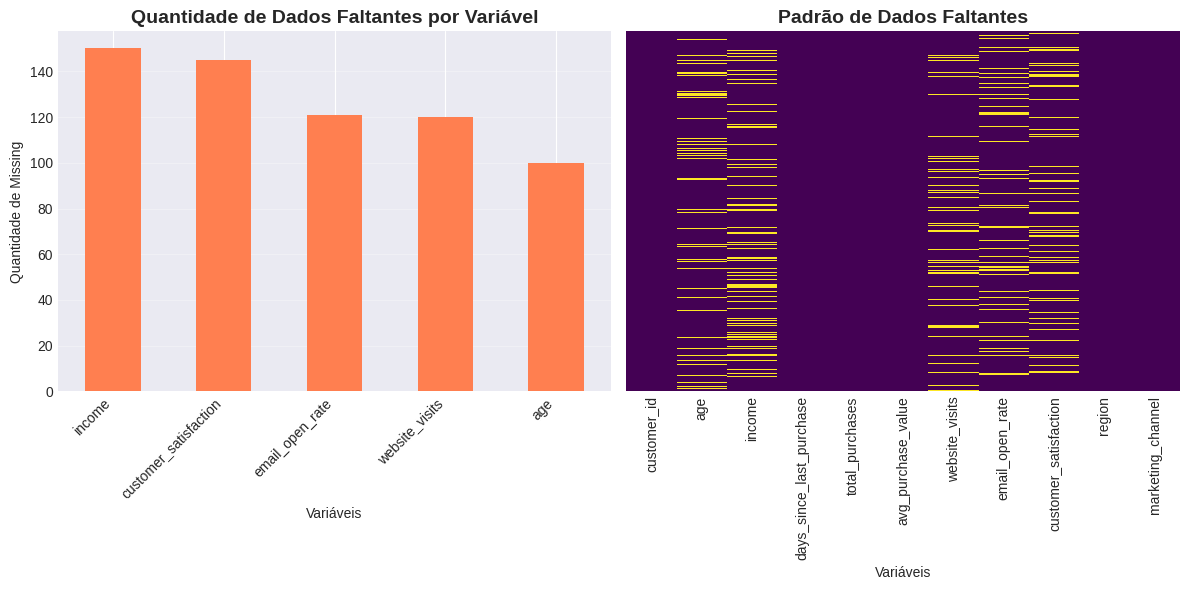

In [6]:
# Visualização de missing data
plt.figure(figsize=(12, 6))

# Gráfico de barras
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.subplot(1, 2, 1)
missing_data.plot(kind='bar', color='coral')
plt.title('Quantidade de Dados Faltantes por Variável', fontsize=14, fontweight='bold')
plt.xlabel('Variáveis')
plt.ylabel('Quantidade de Missing')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Heatmap de missing
plt.subplot(1, 2, 2)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Padrão de Dados Faltantes', fontsize=14, fontweight='bold')
plt.xlabel('Variáveis')

plt.tight_layout()
plt.show()

---

## 3. Técnicas de Tratamento de Missing Data

Agora vamos explorar cada técnica em detalhes.

### 3.1 Listwise Deletion (Remoção de Linhas Completas)

**Conceito:** Remove todas as observações que contêm pelo menos um valor faltante.

**Quando usar:**
- Quando a proporção de missing data é pequena (<5%)
- Quando os dados são MCAR
- Quando você tem um dataset grande

**Vantagens:**
- Simples de implementar
- Não introduz viés se dados são MCAR

**Desvantagens:**
- Perda de informação (pode perder muitos dados)
- Reduz poder estatístico
- Pode introduzir viés se dados não são MCAR

In [7]:
# Implementação de Listwise Deletion

# Antes da remoção
print("Dataset ANTES do Listwise Deletion:")
print(f"Shape: {df.shape}")
print(f"Total de linhas: {len(df)}")
print(f"\nLinhas com pelo menos 1 missing: {df.isnull().any(axis=1).sum()}")
print(f"Linhas completas (sem missing): {(~df.isnull().any(axis=1)).sum()}")

Dataset ANTES do Listwise Deletion:
Shape: (1000, 11)
Total de linhas: 1000

Linhas com pelo menos 1 missing: 489
Linhas completas (sem missing): 511


In [8]:

# Aplicando Listwise Deletion
df_listwise = df.dropna()

# Depois da remoção
print("\n" + "="*60)
print("Dataset DEPOIS do Listwise Deletion:")
print(f"Shape: {df_listwise.shape}")
print(f"Total de linhas: {len(df_listwise)}")
print(f"\nLinhas removidas: {len(df) - len(df_listwise)}")
print(f"Percentual de dados perdidos: {((len(df) - len(df_listwise)) / len(df) * 100):.2f}%")


Dataset DEPOIS do Listwise Deletion:
Shape: (511, 11)
Total de linhas: 511

Linhas removidas: 489
Percentual de dados perdidos: 48.90%


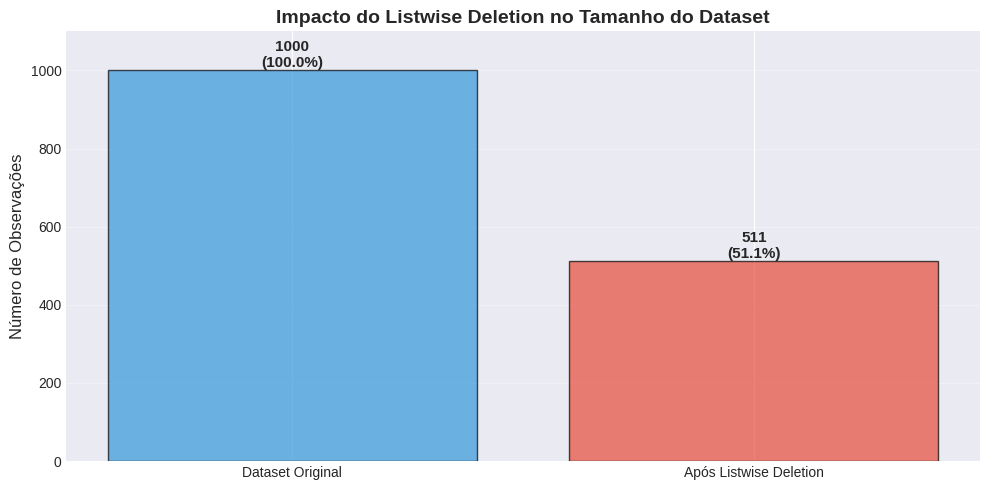


💡 INSIGHT: Perdemos 48.9% dos dados! Isso pode ser problemático.


In [9]:



# Visualização do impacto
plt.figure(figsize=(10, 5))
categories = ['Dataset Original', 'Após Listwise Deletion']
values = [len(df), len(df_listwise)]
colors = ['#3498db', '#e74c3c']

bars = plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Número de Observações', fontsize=12)
plt.title('Impacto do Listwise Deletion no Tamanho do Dataset', fontsize=14, fontweight='bold')
plt.ylim(0, len(df) + 100)

# Adicionando valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Perdemos {:.1f}% dos dados! Isso pode ser problemático.".format(
    (len(df) - len(df_listwise)) / len(df) * 100))

In [10]:
df.describe()

,customer_id,age,income,days_since_last_purchase,total_purchases,avg_purchase_value,website_visits,email_open_rate,customer_satisfaction
count,1000.000000,900.000000,850.000000,1000.000000,1000.000000,1000.000000,880.000000,879.000000,855.000000
mean,500.500000,46.272222,75837.786908,29.253615,4.921000,152.615999,9.903409,71.896871,4.175439
std,288.819436,16.336775,32831.859028,29.038621,2.041795,51.552331,3.184646,16.016705,0.754133
min,1.000000,18.000000,20000.000000,0.000349,0.000000,10.000000,2.000000,12.670000,3.000000
25%,250.750000,33.000000,51689.937195,8.557440,3.750000,118.492453,8.000000,61.710000,4.000000
50%,500.500000,46.500000,71472.398227,20.468715,5.000000,152.989928,10.000000,73.450000,4.000000
75%,750.250000,61.000000,94091.687041,40.642195,6.000000,186.758321,12.000000,84.170000,5.000000
max,1000.000000,74.000000,192676.786697,231.705886,14.000000,318.869146,21.000000,98.950000,5.000000


In [11]:
df_listwise.describe()

,customer_id,age,income,days_since_last_purchase,total_purchases,avg_purchase_value,website_visits,email_open_rate,customer_satisfaction
count,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,487.864971,45.589041,76629.486355,21.322161,4.909980,150.900320,9.968689,72.350489,4.187867
std,287.677549,16.511179,32596.777106,16.055984,2.024293,50.328958,3.125951,15.768418,0.743554
min,1.000000,18.000000,20000.000000,0.000349,0.000000,10.000000,2.000000,23.390000,3.000000
25%,239.500000,31.000000,52856.872838,7.654896,4.000000,117.812454,8.000000,62.535000,4.000000
50%,470.000000,45.000000,71851.760194,17.756436,5.000000,149.301339,10.000000,73.510000,4.000000
75%,733.500000,60.000000,95022.986880,32.991079,6.000000,182.970787,12.000000,84.310000,5.000000
max,1000.000000,74.000000,187958.494597,59.632537,12.000000,318.869146,21.000000,98.950000,5.000000


\
### 3.2 End of Distribution Imputation

**Conceito:** Substitui valores faltantes por um valor nos extremos da distribuição (geralmente média ± 3 desvios padrão).

**Quando usar:**
- Quando você quer que o modelo identifique facilmente observações com imputação
- Para variáveis numéricas com distribuições conhecidas
- Em modelos tree-based que podem lidar bem com outliers

**Vantagens:**
- Preserva todas as observações
- Valores imputados são facilmente identificáveis
- Funciona bem com algoritmos tree-based

**Desvantagens:**
- Cria outliers artificiais
- Distorce a distribuição original
- Pode prejudicar modelos sensíveis a outliers

In [16]:
# Implementação de End of Distribution Imputation

# Vamos aplicar na variável 'income'
df_end_dist = df.copy()

# Função para imputação no final da distribuição
def end_of_distribution_imputation(df, column, direction='upper', std_multiplier=3):
    """
    Imputa valores faltantes no final da distribuição

    Parameters:
    -----------
    df: DataFrame
    column: nome da coluna
    direction: 'upper' (média + std) ou 'lower' (média - std)
    std_multiplier: quantos desvios padrão adicionar/subtrair
    """
    mean = df[column].mean()
    std = df[column].std()

    if direction == 'upper':
        impute_value = mean + (std_multiplier * std)
    else:
        impute_value = mean - (std_multiplier * std)

    # Número de valores faltantes
    n_missing = df[column].isnull().sum()

    # Imputação
    df[column].fillna(impute_value, inplace=True)

    return df, impute_value, n_missing


In [14]:
# Aplicando para income (final superior da distribuição)
df_end_dist, impute_val, n_miss = end_of_distribution_imputation(
    df_end_dist, 'income', direction='upper', std_multiplier=3
)

End of Distribution Imputation - Income
Média original: R$ 75,837.79
Desvio padrão: R$ 32,831.86
Valor imputado (μ + 3σ): R$ 174,333.36
Valores imputados: 150


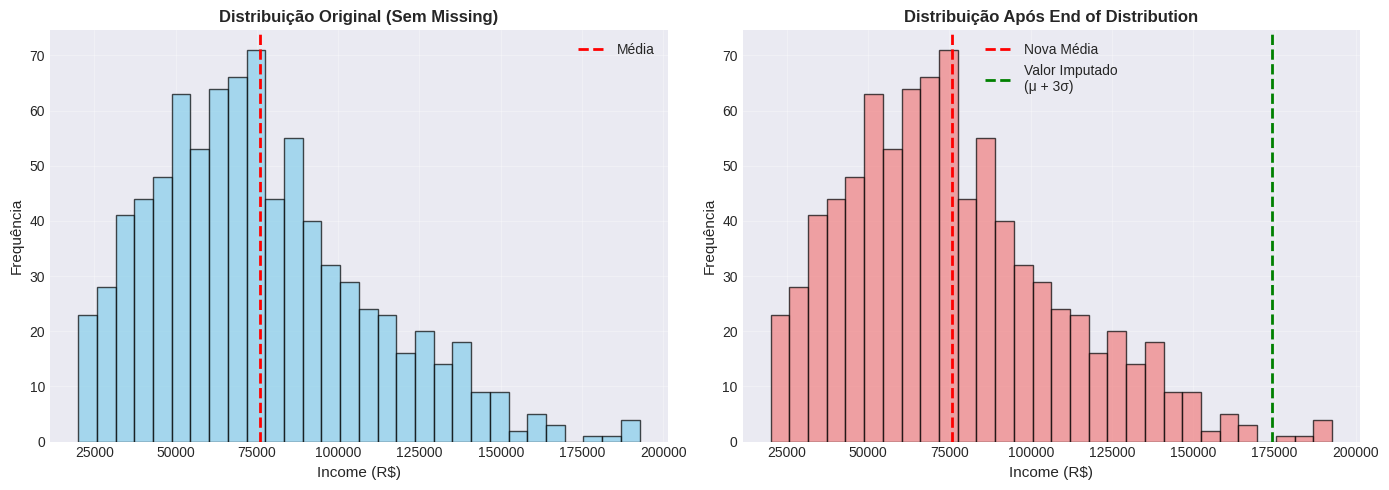


💡 INSIGHT: Observe o pico no final da distribuição (outliers artificiais)


In [17]:
print("End of Distribution Imputation - Income")
print("="*60)
print(f"Média original: R$ {df['income'].mean():,.2f}")
print(f"Desvio padrão: R$ {df['income'].std():,.2f}")
print(f"Valor imputado (μ + 3σ): R$ {impute_val:,.2f}")
print(f"Valores imputados: {n_miss}")

# Visualização comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição original (sem missing)
axes[0].hist(df['income'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['income'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
axes[0].set_xlabel('Income (R$)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição Original (Sem Missing)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribuição após imputação
axes[1].hist(df_end_dist['income'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(df_end_dist['income'].mean(), color='red', linestyle='--', linewidth=2, label='Nova Média')
axes[1].axvline(impute_val, color='green', linestyle='--', linewidth=2, label=f'Valor Imputado\n(μ + 3σ)')
axes[1].set_xlabel('Income (R$)', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].set_title('Distribuição Após End of Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Observe o pico no final da distribuição (outliers artificiais)")

### 3.3 Mean/Median/Mode Imputation (Imputação por Medidas Centrais)

**Conceito:** Substitui valores faltantes pela média, mediana ou moda da variável.

**Quando usar:**
- **Média**: Distribuições simétricas, dados sem outliers significativos
- **Mediana**: Distribuições assimétricas, presença de outliers
- **Moda**: Variáveis categóricas

**Vantagens:**
- Fácil de implementar
- Preserva o tamanho do dataset
- Funciona bem quando % de missing é baixo

**Desvantagens:**
- Reduz variância dos dados
- Distorce distribuição
- Pode subestimar relações entre variáveis

In [18]:
# Implementação de Mean/Median/Mode Imputation

df_central = df.copy()

# Função para escolher a melhor medida central
def analyze_distribution(df, column):
    """
    Analisa a distribuição e recomenda a melhor medida central
    """
    data = df[column].dropna()

    # Cálculo de métricas
    mean_val = data.mean()
    median_val = data.median()
    skewness = stats.skew(data)

    # Decisão baseada em assimetria
    if abs(skewness) < 0.5:
        recommendation = 'mean'
        reason = 'Distribuição simétrica'
    else:
        recommendation = 'median'
        reason = f'Distribuição assimétrica (skewness={skewness:.2f})'

    return {
        'mean': mean_val,
        'median': median_val,
        'skewness': skewness,
        'recommendation': recommendation,
        'reason': reason
    }



In [19]:
# Análise para 'age'
age_analysis = analyze_distribution(df, 'age')
print("Análise da variável 'age':")
print("="*60)
print(f"Média: {age_analysis['mean']:.2f}")
print(f"Mediana: {age_analysis['median']:.2f}")
print(f"Skewness: {age_analysis['skewness']:.2f}")
print(f"Recomendação: {age_analysis['recommendation'].upper()}")
print(f"Razão: {age_analysis['reason']}")

print("\n" + "="*60)


Análise da variável 'age':
Média: 46.27
Mediana: 46.50
Skewness: -0.04
Recomendação: MEAN
Razão: Distribuição simétrica



In [20]:

# Análise para 'website_visits'
visits_analysis = analyze_distribution(df, 'website_visits')
print("Análise da variável 'website_visits':")
print("="*60)
print(f"Média: {visits_analysis['mean']:.2f}")
print(f"Mediana: {visits_analysis['median']:.2f}")
print(f"Skewness: {visits_analysis['skewness']:.2f}")
print(f"Recomendação: {visits_analysis['recommendation'].upper()}")
print(f"Razão: {visits_analysis['reason']}")




Análise da variável 'website_visits':
Média: 9.90
Mediana: 10.00
Skewness: 0.30
Recomendação: MEAN
Razão: Distribuição simétrica

Aplicando Imputações...


In [23]:
# Aplicando as imputações
print("\n" + "="*60)
print("Aplicando Imputações...")
print("="*60)

# Age - usando média (distribuição simétrica)
age_missing = df_central['age'].isnull().sum()
df_central['age'].fillna(df_central['age'].mean(), inplace=True)
print(f"✓ Age: {age_missing} valores imputados com MÉDIA ({age_analysis['mean']:.2f})")

# Website visits - usando mediana (distribuição pode ter outliers)
visits_missing = df_central['website_visits'].isnull().sum()
df_central['website_visits'].fillna(df_central['website_visits'].median(), inplace=True)
print(f"✓ Website Visits: {visits_missing} valores imputados com MEDIANA ({visits_analysis['median']:.2f})")

# Customer Satisfaction - usando MODA (variável categórica/ordinal)
satisfaction_missing = df_central['customer_satisfaction'].isnull().sum()
mode_satisfaction = df_central['customer_satisfaction'].mode()[0]
df_central['customer_satisfaction'].fillna(mode_satisfaction, inplace=True)
print(f"✓ Customer Satisfaction: {satisfaction_missing} valores imputados com MODA ({mode_satisfaction})")


Aplicando Imputações...
✓ Age: 0 valores imputados com MÉDIA (46.27)
✓ Website Visits: 0 valores imputados com MEDIANA (10.00)
✓ Customer Satisfaction: 0 valores imputados com MODA (4.0)


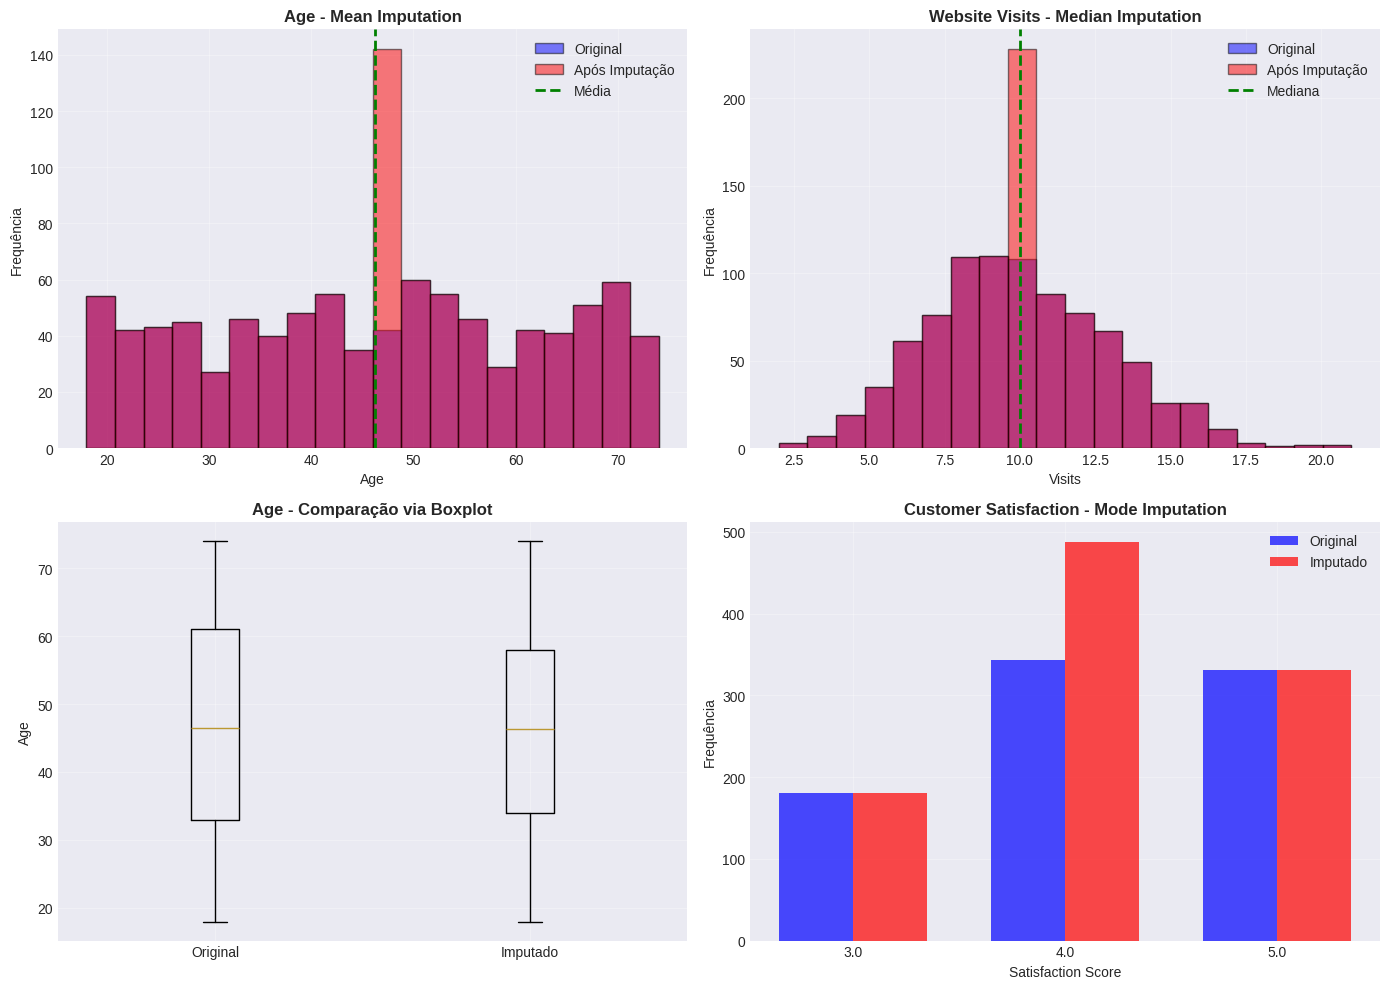


💡 INSIGHT: Observe o pico nas medidas centrais após imputação
Isso reduz a variância e pode impactar modelos estatísticos!


In [26]:
# Visualização do impacto nas distribuições
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age - Original vs Imputada
axes[0, 0].hist(df['age'], bins=20, alpha=0.5, label='Original', color='blue', edgecolor='black')
axes[0, 0].hist(df_central['age'], bins=20, alpha=0.5, label='Após Imputação', color='red', edgecolor='black')
axes[0, 0].axvline(age_analysis['mean'], color='green', linestyle='--', linewidth=2, label='Média')
axes[0, 0].set_title('Age - Mean Imputation', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Website Visits - Original vs Imputada
axes[0, 1].hist(df['website_visits'], bins=20, alpha=0.5, label='Original', color='blue', edgecolor='black')
axes[0, 1].hist(df_central['website_visits'], bins=20, alpha=0.5, label='Após Imputação', color='red', edgecolor='black')
axes[0, 1].axvline(visits_analysis['median'], color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0, 1].set_title('Website Visits - Median Imputation', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Visits')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Boxplots comparativos
comparison_age = pd.DataFrame({
    'Original': df['age'],
    'Imputado': df_central['age']
})
axes[1, 0].boxplot([comparison_age['Original'].dropna(), comparison_age['Imputado']],
                   labels=['Original', 'Imputado'])
axes[1, 0].set_title('Age - Comparação via Boxplot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Age')
axes[1, 0].grid(alpha=0.3)

# Customer Satisfaction - Distribuição de frequência
satisfaction_original = df['customer_satisfaction'].value_counts().sort_index()
satisfaction_imputed = df_central['customer_satisfaction'].value_counts().sort_index()

x = np.arange(len(satisfaction_original))
width = 0.35
axes[1, 1].bar(x - width/2, satisfaction_original.values, width, label='Original', alpha=0.7, color='blue')
axes[1, 1].bar(x + width/2, satisfaction_imputed.values, width, label='Imputado', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Satisfaction Score')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Customer Satisfaction - Mode Imputation', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(satisfaction_original.index)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Observe o pico nas medidas centrais após imputação")
print("Isso reduz a variância e pode impactar modelos estatísticos!")

### 3.4 Random Imputation (Imputação Aleatória)

**Conceito:** Substitui valores faltantes por valores aleatórios retirados da própria distribuição da variável.

**Quando usar:**
- Quando você quer preservar a distribuição original
- Para dados MCAR
- Quando a variância é importante para análise

**Vantagens:**
- Preserva a distribuição dos dados
- Mantém a variância aproximada
- Mais realista que média/mediana

**Desvantagens:**
- Introduz aleatoriedade (resultados podem variar)
- Pode subestimar correlações entre variáveis
- Não captura relações com outras features

In [27]:
# Implementação de Random Imputation

df_random = df.copy()

def random_imputation(df, column, seed=42):
    """
    Imputa valores faltantes com valores aleatórios da própria distribuição

    Parameters:
    -----------
    df: DataFrame
    column: nome da coluna
    seed: semente para reprodutibilidade
    """
    np.random.seed(seed)

    # Identificar valores faltantes
    missing_mask = df[column].isnull()
    n_missing = missing_mask.sum()

    if n_missing > 0:
        # Valores não-faltantes
        available_values = df.loc[~missing_mask, column].values

        # Amostragem aleatória
        random_sample = np.random.choice(available_values, size=n_missing, replace=True)

        # Imputação
        df.loc[missing_mask, column] = random_sample

    return df, n_missing



In [29]:
# Aplicando Random Imputation em 'email_open_rate'
print("Random Imputation - Email Open Rate")
print("="*60)
print(f"Valores faltantes antes: {df_random['email_open_rate'].isnull().sum()}")

df_random, n_imputed = random_imputation(df_random, 'email_open_rate', seed=42)

print(f"Valores imputados: {n_imputed}")
print(f"Valores faltantes após: {df_random['email_open_rate'].isnull().sum()}")

# Estatísticas comparativas
print("\nEstatísticas Comparativas:")
print("="*60)
stats_comparison = pd.DataFrame({
    'Original': [
        df['email_open_rate'].mean(),
        df['email_open_rate'].std(),
        df['email_open_rate'].min(),
        df['email_open_rate'].max()
    ],
    'Random Imputation': [
        df_random['email_open_rate'].mean(),
        df_random['email_open_rate'].std(),
        df_random['email_open_rate'].min(),
        df_random['email_open_rate'].max()
    ]
}, index=['Média', 'Desvio Padrão', 'Mínimo', 'Máximo'])

print(stats_comparison.round(2))

Random Imputation - Email Open Rate
Valores faltantes antes: 0
Valores imputados: 0
Valores faltantes após: 0

Estatísticas Comparativas:
               Original  Random Imputation
Média             71.90              71.90
Desvio Padrão     16.02              15.96
Mínimo            12.67              12.67
Máximo            98.95              98.95


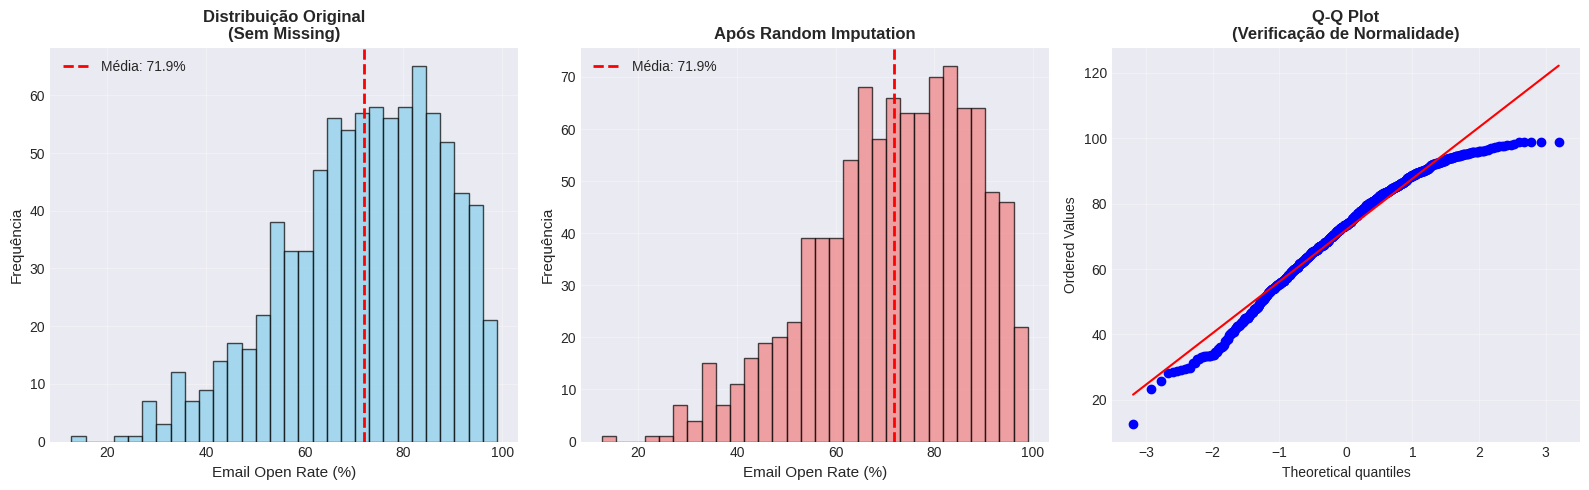


💡 INSIGHT: A distribuição foi preservada! Compare as estatísticas acima.
Random Imputation mantém características da distribuição original.


In [31]:
# Visualização comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma - Distribuição Original
axes[0].hist(df['email_open_rate'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Email Open Rate (%)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição Original\n(Sem Missing)', fontsize=12, fontweight='bold')
axes[0].axvline(df['email_open_rate'].mean(), color='red', linestyle='--',
               linewidth=2, label=f"Média: {df['email_open_rate'].mean():.1f}%")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma - Após Random Imputation
axes[1].hist(df_random['email_open_rate'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Email Open Rate (%)', fontsize=11)
axes[1].set_ylabel('Frequência', fontsize=11)
axes[1].set_title('Após Random Imputation', fontsize=12, fontweight='bold')
axes[1].axvline(df_random['email_open_rate'].mean(), color='red', linestyle='--',
               linewidth=2, label=f"Média: {df_random['email_open_rate'].mean():.1f}%")
axes[1].legend()
axes[1].grid(alpha=0.3)

# QQ-Plot para verificar se mantém distribuição
stats.probplot(df_random['email_open_rate'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot\n(Verificação de Normalidade)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: A distribuição foi preservada! Compare as estatísticas acima.")
print("Random Imputation mantém características da distribuição original.")

### 3.5 Arbitrary Value Imputation (Imputação com Valor Arbitrário)

**Conceito:** Substitui valores faltantes por um valor arbitrário definido pelo usuário (ex: -999, 0, -1).

**Quando usar:**
- Quando missing tem significado específico (ex: "Não aplicável")
- Para variáveis onde queremos que o modelo trate missing de forma especial
- Em conjunto com algoritmos tree-based

**Vantagens:**
- Preserva a informação de que o dado estava faltando
- Simples de implementar
- O modelo pode aprender padrões específicos de missing

**Desvantagens:**
- O valor arbitrário pode criar viés
- Pode ser mal interpretado como um valor real
- Distorce distribuições e estatísticas

In [32]:
# Implementação de Arbitrary Value Imputation

df_arbitrary = df.copy()

def arbitrary_value_imputation(df, column, fill_value, name='Arbitrary'):
    """
    Imputa valores faltantes com valor arbitrário

    Parameters:
    -----------
    df: DataFrame
    column: nome da coluna
    fill_value: valor a ser usado na imputação
    name: nome descritivo do valor
    """
    n_missing = df[column].isnull().sum()
    df[column].fillna(fill_value, inplace=True)

    return df, n_missing, fill_value

# Exemplo 1: Income com valor -1 (indicando "não informado")
print("Arbitrary Value Imputation - Income")
print("="*60)
print("Estratégia: Usar -1 para indicar 'Income não informado'")
print(f"Valores faltantes: {df_arbitrary['income'].isnull().sum()}")

df_arbitrary, n_imp_income, val_income = arbitrary_value_imputation(
    df_arbitrary, 'income', fill_value=-1, name='Não Informado'
)

print(f"Valores imputados com {val_income}: {n_imp_income}")
print(f"Valores faltantes após: {df_arbitrary['income'].isnull().sum()}")

# Exemplo 2: Email Open Rate com 0 (indicando "não recebeu email" ou "não abriu")
print("\n" + "="*60)
print("Arbitrary Value Imputation - Email Open Rate")
print("="*60)
print("Estratégia: Usar 0 para indicar 'Não recebeu/abriu email'")
print(f"Valores faltantes: {df_arbitrary['email_open_rate'].isnull().sum()}")

df_arbitrary, n_imp_email, val_email = arbitrary_value_imputation(
    df_arbitrary, 'email_open_rate', fill_value=0, name='Não Abriu'
)

print(f"Valores imputados com {val_email}: {n_imp_email}")
print(f"Valores faltantes após: {df_arbitrary['email_open_rate'].isnull().sum()}")

Arbitrary Value Imputation - Income
Estratégia: Usar -1 para indicar 'Income não informado'
Valores faltantes: 150
Valores imputados com -1: 150
Valores faltantes após: 0

Arbitrary Value Imputation - Email Open Rate
Estratégia: Usar 0 para indicar 'Não recebeu/abriu email'
Valores faltantes: 121
Valores imputados com 0: 121
Valores faltantes após: 0


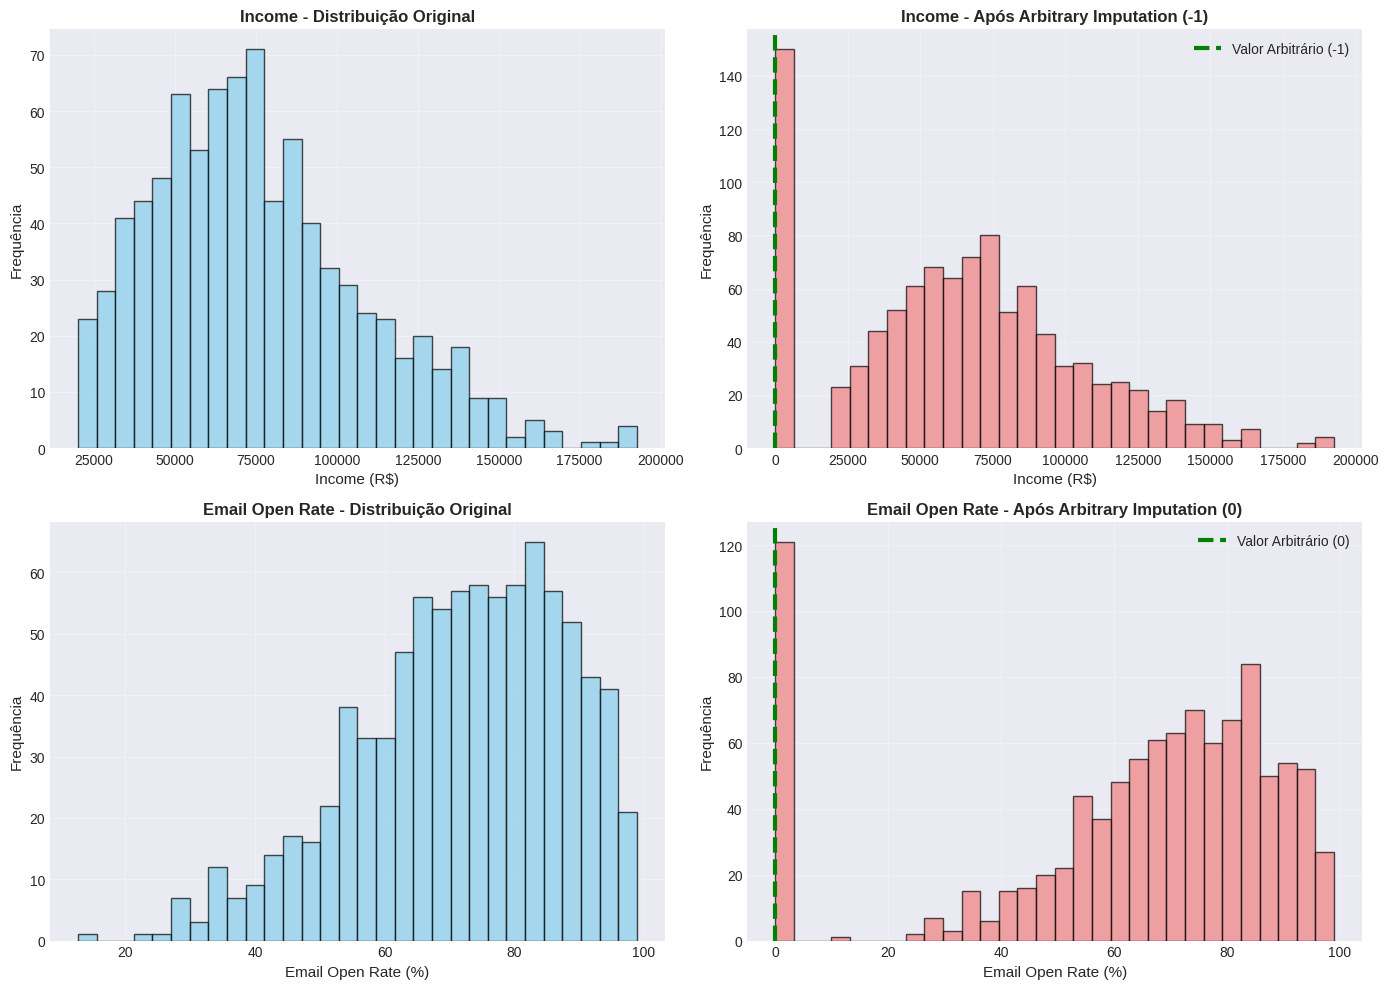


💡 INSIGHT: Valores arbitrários são facilmente identificáveis!
Útil para modelos baseados em árvores (Random Forest, XGBoost)
que podem criar regras específicas para esses valores.


In [34]:
# Visualização do impacto
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income - Distribuição original
axes[0, 0].hist(df['income'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Income (R$)', fontsize=11)
axes[0, 0].set_ylabel('Frequência', fontsize=11)
axes[0, 0].set_title('Income - Distribuição Original', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Income - Após arbitrary imputation
axes[0, 1].hist(df_arbitrary['income'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].axvline(-1, color='green', linestyle='--', linewidth=3, label='Valor Arbitrário (-1)')
axes[0, 1].set_xlabel('Income (R$)', fontsize=11)
axes[0, 1].set_ylabel('Frequência', fontsize=11)
axes[0, 1].set_title('Income - Após Arbitrary Imputation (-1)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Email Open Rate - Distribuição original
axes[1, 0].hist(df['email_open_rate'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Email Open Rate (%)', fontsize=11)
axes[1, 0].set_ylabel('Frequência', fontsize=11)
axes[1, 0].set_title('Email Open Rate - Distribuição Original', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Email Open Rate - Após arbitrary imputation
axes[1, 1].hist(df_arbitrary['email_open_rate'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].axvline(0, color='green', linestyle='--', linewidth=3, label='Valor Arbitrário (0)')
axes[1, 1].set_xlabel('Email Open Rate (%)', fontsize=11)
axes[1, 1].set_ylabel('Frequência', fontsize=11)
axes[1, 1].set_title('Email Open Rate - Após Arbitrary Imputation (0)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Valores arbitrários são facilmente identificáveis!")
print("Útil para modelos baseados em árvores (Random Forest, XGBoost)")
print("que podem criar regras específicas para esses valores.")

### 3.6 Add Variable to Denote (Adicionar Variável Indicadora)

**Conceito:** Cria uma variável binária (flag) que indica se o valor original estava faltando (1) ou não (0), antes de fazer a imputação.

**Quando usar:**
- Quando a ausência do dado pode ser informativa para o modelo
- Em conjunto com qualquer técnica de imputação
- Quando queremos capturar padrões de missing data

**Vantagens:**
- Preserva a informação de que o dado estava faltando
- Permite ao modelo aprender padrões relacionados aos missing
- Pode melhorar performance preditiva

**Desvantagens:**
- Aumenta dimensionalidade do dataset
- Pode criar multicolinearidade
- Features extras podem não ser úteis

In [35]:
# Implementação de Add Variable to Denote

df_flag = df.copy()

def add_missing_indicator(df, columns, imputation_method='mean'):
    """
    Adiciona variável indicadora de missing e faz imputação

    Parameters:
    -----------
    df: DataFrame
    columns: lista de colunas para processar
    imputation_method: 'mean', 'median', 'mode'
    """
    for column in columns:
        # Criar variável indicadora ANTES da imputação
        indicator_name = f'{column}_was_missing'
        df[indicator_name] = df[column].isnull().astype(int)

        # Imputação
        if imputation_method == 'mean':
            fill_value = df[column].mean()
        elif imputation_method == 'median':
            fill_value = df[column].median()
        elif imputation_method == 'mode':
            fill_value = df[column].mode()[0]

        df[column].fillna(fill_value, inplace=True)

    return df

# Lista de colunas para processar
cols_to_process = ['income', 'age', 'email_open_rate', 'website_visits']

print("Add Variable to Denote (Flag de Missing)")
print("="*60)
print("Criando variáveis indicadoras e aplicando imputações...\n")

# Estatísticas antes
print("Missing Data ANTES:")
for col in cols_to_process:
    n_missing = df_flag[col].isnull().sum()
    pct_missing = (n_missing / len(df_flag)) * 100
    print(f"  {col}: {n_missing} ({pct_missing:.1f}%)")

# Aplicar a técnica
df_flag = add_missing_indicator(df_flag, cols_to_process, imputation_method='mean')

print("\n" + "="*60)
print("Variáveis Indicadoras Criadas:")
indicator_cols = [col for col in df_flag.columns if '_was_missing' in col]
for col in indicator_cols:
    n_flagged = df_flag[col].sum()
    pct_flagged = (n_flagged / len(df_flag)) * 100
    print(f"  {col}: {n_flagged} registros marcados ({pct_flagged:.1f}%)")

print("\n" + "="*60)
print(f"Dimensionalidade do Dataset:")
print(f"  Antes: {df.shape}")
print(f"  Depois: {df_flag.shape}")
print(f"  Novas features: {len(indicator_cols)}")

Add Variable to Denote (Flag de Missing)
Criando variáveis indicadoras e aplicando imputações...

Missing Data ANTES:
  income: 150 (15.0%)
  age: 100 (10.0%)
  email_open_rate: 121 (12.1%)
  website_visits: 120 (12.0%)

Variáveis Indicadoras Criadas:
  income_was_missing: 150 registros marcados (15.0%)
  age_was_missing: 100 registros marcados (10.0%)
  email_open_rate_was_missing: 121 registros marcados (12.1%)
  website_visits_was_missing: 120 registros marcados (12.0%)

Dimensionalidade do Dataset:
  Antes: (1000, 11)
  Depois: (1000, 15)
  Novas features: 4



Amostra do Dataset com Flags:
   customer_id         income  income_was_missing   age  age_was_missing  \
0            1   22106.197270                   0  56.0                0   
1            2   67151.710539                   0  69.0                0   
2            3   82563.782781                   0  46.0                0   
3            4   43747.762934                   0  32.0                0   
4            5   67988.545135                   0  60.0                0   
5            6  105735.725849                   0  25.0                0   
6            7   54185.212178                   0  38.0                0   
7            8   47323.036213                   0  56.0                0   
8            9   66588.782126                   0  36.0                0   
9           10   41527.616283                   0  40.0                0   

   email_open_rate  email_open_rate_was_missing  
0        84.110000                            0  
1        89.820000              

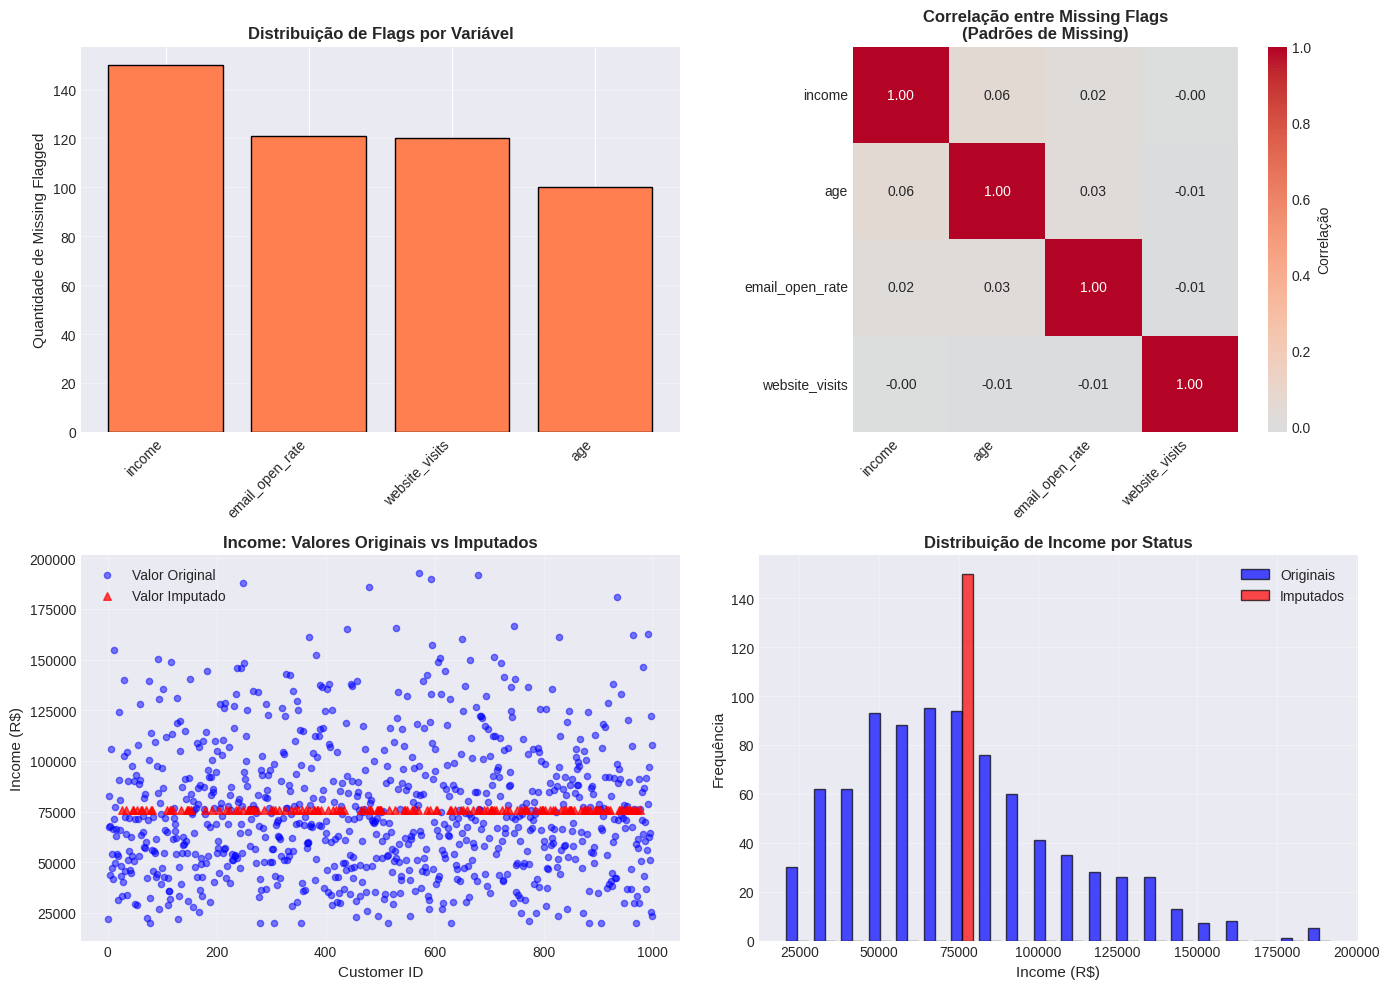


💡 INSIGHT: As flags permitem ao modelo ML 'aprender' que o dado estava faltando!
Exemplo: Se clientes com 'income_was_missing=1' tendem a comprar menos,
o modelo pode usar essa informação para melhorar predições.


In [36]:
# Análise das variáveis indicadoras
print("\nAmostra do Dataset com Flags:")
print("="*60)
display_cols = ['customer_id', 'income', 'income_was_missing', 'age', 'age_was_missing',
                'email_open_rate', 'email_open_rate_was_missing']
print(df_flag[display_cols].head(10))

# Visualização das flags
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico de barras - Flags criadas
flag_summary = df_flag[indicator_cols].sum().sort_values(ascending=False)
axes[0, 0].bar(range(len(flag_summary)), flag_summary.values, color='coral', edgecolor='black')
axes[0, 0].set_xticks(range(len(flag_summary)))
axes[0, 0].set_xticklabels([col.replace('_was_missing', '') for col in flag_summary.index],
                          rotation=45, ha='right')
axes[0, 0].set_ylabel('Quantidade de Missing Flagged', fontsize=11)
axes[0, 0].set_title('Distribuição de Flags por Variável', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Matriz de correlação entre flags
corr_matrix = df_flag[indicator_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, ax=axes[0, 1], cbar_kws={'label': 'Correlação'})
axes[0, 1].set_title('Correlação entre Missing Flags\n(Padrões de Missing)',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels([col.replace('_was_missing', '') for col in indicator_cols],
                          rotation=45, ha='right')
axes[0, 1].set_yticklabels([col.replace('_was_missing', '') for col in indicator_cols],
                          rotation=0)

# Comparação: Income original vs imputado (colorido por flag)
axes[1, 0].scatter(df_flag[df_flag['income_was_missing']==0]['customer_id'],
                  df_flag[df_flag['income_was_missing']==0]['income'],
                  alpha=0.5, label='Valor Original', s=20, color='blue')
axes[1, 0].scatter(df_flag[df_flag['income_was_missing']==1]['customer_id'],
                  df_flag[df_flag['income_was_missing']==1]['income'],
                  alpha=0.7, label='Valor Imputado', s=30, color='red', marker='^')
axes[1, 0].set_xlabel('Customer ID', fontsize=11)
axes[1, 0].set_ylabel('Income (R$)', fontsize=11)
axes[1, 0].set_title('Income: Valores Originais vs Imputados', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Distribuição de income por flag
data_original = df_flag[df_flag['income_was_missing']==0]['income']
data_imputed = df_flag[df_flag['income_was_missing']==1]['income']
axes[1, 1].hist([data_original, data_imputed], bins=20, alpha=0.7,
               label=['Originais', 'Imputados'], color=['blue', 'red'], edgecolor='black')
axes[1, 1].set_xlabel('Income (R$)', fontsize=11)
axes[1, 1].set_ylabel('Frequência', fontsize=11)
axes[1, 1].set_title('Distribuição de Income por Status', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: As flags permitem ao modelo ML 'aprender' que o dado estava faltando!")
print("Exemplo: Se clientes com 'income_was_missing=1' tendem a comprar menos,")
print("o modelo pode usar essa informação para melhorar predições.")

---

## 4. Comparação Final das Técnicas

Vamos comparar todas as técnicas aplicadas:


COMPARAÇÃO FINAL DAS TÉCNICAS
            Técnica  Observações  Features  Missing Total Preserva Distribuição Preserva Variância Complexidade
  Listwise Deletion          511        11              0                     ❌                  ✅        Baixa
End of Distribution         1000        11            636                     ❌                  ❌        Média
   Mean/Median/Mode         1000        11            271                    ⚠️                  ❌        Baixa
  Random Imputation         1000        11            515                     ✅                  ✅        Baixa
    Arbitrary Value         1000        11            365                     ❌                  ❌        Baixa
  Add Variable Flag         1000        15            145                     ✅                  ✅        Média


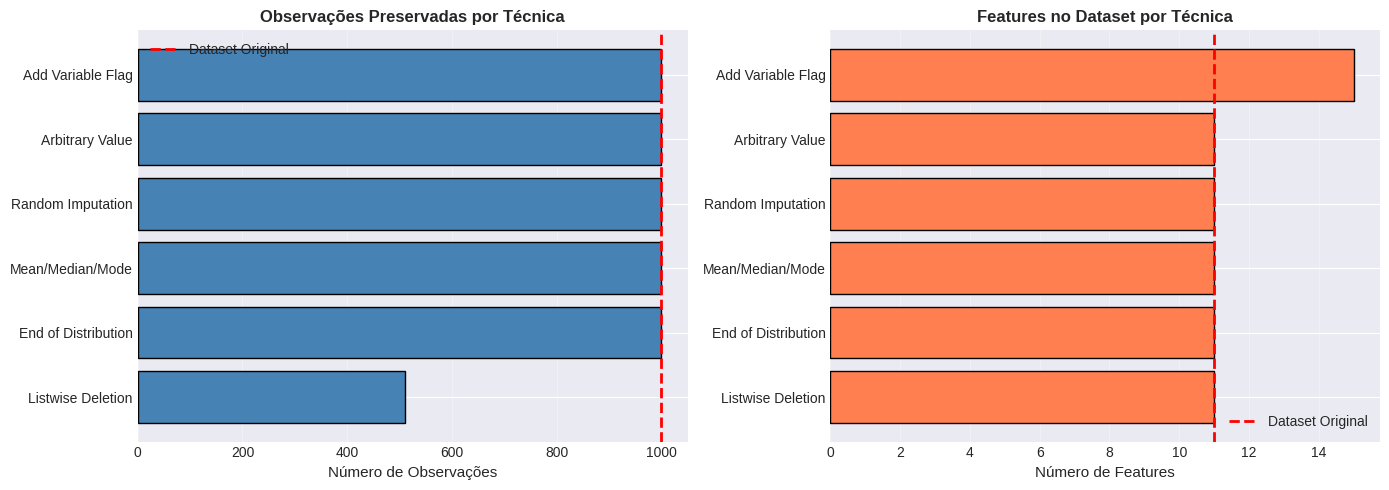

In [37]:
# Resumo comparativo
comparison_data = {
    'Técnica': [
        'Listwise Deletion',
        'End of Distribution',
        'Mean/Median/Mode',
        'Random Imputation',
        'Arbitrary Value',
        'Add Variable Flag'
    ],
    'Observações': [
        len(df_listwise),
        len(df_end_dist),
        len(df_central),
        len(df_random),
        len(df_arbitrary),
        len(df_flag)
    ],
    'Features': [
        df_listwise.shape[1],
        df_end_dist.shape[1],
        df_central.shape[1],
        df_random.shape[1],
        df_arbitrary.shape[1],
        df_flag.shape[1]
    ],
    'Missing Total': [
        df_listwise.isnull().sum().sum(),
        df_end_dist.isnull().sum().sum(),
        df_central.isnull().sum().sum(),
        df_random.isnull().sum().sum(),
        df_arbitrary.isnull().sum().sum(),
        df_flag.isnull().sum().sum()
    ],
    'Preserva Distribuição': [
        '❌',
        '❌',
        '⚠️',
        '✅',
        '❌',
        '✅'
    ],
    'Preserva Variância': [
        '✅',
        '❌',
        '❌',
        '✅',
        '❌',
        '✅'
    ],
    'Complexidade': [
        'Baixa',
        'Média',
        'Baixa',
        'Baixa',
        'Baixa',
        'Média'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("COMPARAÇÃO FINAL DAS TÉCNICAS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparação de observações preservadas
axes[0].barh(comparison_df['Técnica'], comparison_df['Observações'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Número de Observações', fontsize=11)
axes[0].set_title('Observações Preservadas por Técnica', fontsize=12, fontweight='bold')
axes[0].axvline(len(df), color='red', linestyle='--', linewidth=2, label='Dataset Original')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Comparação de features
axes[1].barh(comparison_df['Técnica'], comparison_df['Features'], color='coral', edgecolor='black')
axes[1].set_xlabel('Número de Features', fontsize=11)
axes[1].set_title('Features no Dataset por Técnica', fontsize=12, fontweight='bold')
axes[1].axvline(df.shape[1], color='red', linestyle='--', linewidth=2, label='Dataset Original')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Guia de Decisão: Qual Técnica Usar?

### 🎯 Decision Tree para Escolher a Técnica

```
% de Missing < 5%?
├── SIM → Considere LISTWISE DELETION
└── NÃO → Continue...
    |
    Missing é MCAR?
    ├── SIM → RANDOM IMPUTATION ou MEAN/MEDIAN
    └── NÃO → Continue...
        |
        Missing tem significado especial?
        ├── SIM → ARBITRARY VALUE + ADD FLAG
        └── NÃO → Continue...
            |
            Usando Tree-Based Models?
            ├── SIM → END OF DISTRIBUTION ou ARBITRARY
            └── NÃO → RANDOM ou MEAN/MEDIAN + ADD FLAG
```

### 📊 Recomendações por Contexto de Negócio:

| Cenário | Técnica Recomendada | Justificativa |
|---------|-------------------|---------------|
| **Análise Exploratória** | Listwise Deletion | Simplicidade, evita viés artificial |
| **Modelos Lineares** | Mean/Median + Flag | Preserva relações lineares |
| **Random Forest/XGBoost** | Arbitrary Value ou End of Distribution | Algoritmos robustos a outliers |
| **Deep Learning** | Random Imputation + Flag | Preserva distribuições |
| **Dados de Pesquisa** | Mode Imputation | Comum em dados categóricos |
| **Séries Temporais** | Forward/Backward Fill | (Não coberto, mas importante!) |

---

## 6. 🎓 EXERCÍCIO PRÁTICO PARA OS ALUNOS

### Dataset: Customer Churn (Cancelamento de Clientes)

**Contexto:** Você trabalha em uma empresa de telecom e precisa prever quais clientes vão cancelar o serviço (churn). O dataset contém dados faltantes que precisam ser tratados antes de treinar o modelo.

**Objetivo:** Aplicar as técnicas aprendidas para tratar os dados faltantes e preparar o dataset para modelagem.

---

---

### 📝 INSTRUÇÕES DO EXERCÍCIO

**Seu desafio é preparar este dataset para modelagem seguindo os passos abaixo:**

#### **Etapa 1: Análise Exploratória (EDA)**
1. Visualize o padrão de missing data com heatmap
2. Calcule estatísticas descritivas das variáveis
3. Identifique se há correlações entre variáveis com missing

#### **Etapa 2: Decisão de Estratégia**
Para cada variável com missing, decida e **justifique** qual técnica usar:

- **tenure_months**: ?
- **monthly_charges**: ?
- **total_charges**: ?
- **customer_satisfaction**: ?
- **num_support_tickets**: ?
- **tech_support**: ?

#### **Etapa 3: Implementação**
1. Aplique **pelo menos 4 técnicas diferentes** aprendidas hoje
2. Crie **pelo menos 2 variáveis indicadoras (flags)**
3. Documente seu código com comentários explicativos

#### **Etapa 4: Validação**
1. Compare estatísticas antes/depois da imputação
2. Visualize distribuições originais vs imputadas
3. Verifique se não há mais missing data

#### **Etapa 5: Reflexão**
Responda:
1. Qual técnica você usaria em um cenário real? Por quê?
2. Quais riscos você identificou ao usar cada técnica?
3. Como você validaria se sua estratégia foi bem-sucedida?

---

### 💡 DICAS:
- Lembre-se que `total_charges` depende de `monthly_charges` e `tenure_months`
- Variáveis categóricas requerem tratamento diferente
- Pense no impacto de cada técnica no modelo de Machine Learning
- Use visualizações para comunicar suas decisões

### ⏰ Tempo Estimado: 45-60 minutos

---

In [ ]:
# ESPAÇO PARA RESOLVER O EXERCÍCIO
# Escreva seu código aqui

# Dica: Comece criando uma cópia do dataset
df_solution = df_exercise.copy()

# Etapa 1: EDA
# Seu código aqui...



# Etapa 2: Estratégia
# Seu código aqui...



# Etapa 3: Implementação
# Seu código aqui...



# Etapa 4: Validação
# Seu código aqui...




---

## 📚 Referências e Leituras Complementares

1. **Little, R. J., & Rubin, D. B. (2019).** Statistical analysis with missing data (Vol. 793). John Wiley & Sons.

2. **Géron, A. (2019).** Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. O'Reilly Media.

3. **Feature-engine Documentation:** https://feature-engine.readthedocs.io/en/latest/user_guide/imputation/

4. **Scikit-learn Imputation:** https://scikit-learn.org/stable/modules/impute.html

---

## 🎯 Conclusões

### Key Takeaways:

1. **Não existe técnica perfeita** - a escolha depende do contexto
2. **Entenda seus dados** - o mecanismo de missing (MCAR, MAR, MNAR) importa
3. **Combine técnicas** - usar flags + imputação geralmente funciona bem
4. **Valide suas escolhas** - sempre compare resultados antes/depois
5. **Documente decisões** - justifique suas escolhas para stakeholders

### Boas Práticas:
- ✅ Sempre faça EDA antes de decidir
- ✅ Preserve dados originais (trabalhe em cópias)
- ✅ Documente qual técnica foi usada em cada variável
- ✅ Valide com domain experts quando possível
- ✅ Considere impacto no modelo downstream

---

**Dúvidas? Entre em contato!**

**Bons estudos! 🚀**